In [1]:
import torch
import os
import random
import nibabel as nib
import matplotlib.pyplot as plt
import numpy as np

Đang hiển thị file: OAS1_0031_MR1
Shape of the 3D image: (153, 133, 132)
Mid coordinates: X=110, Y=110, Z=110


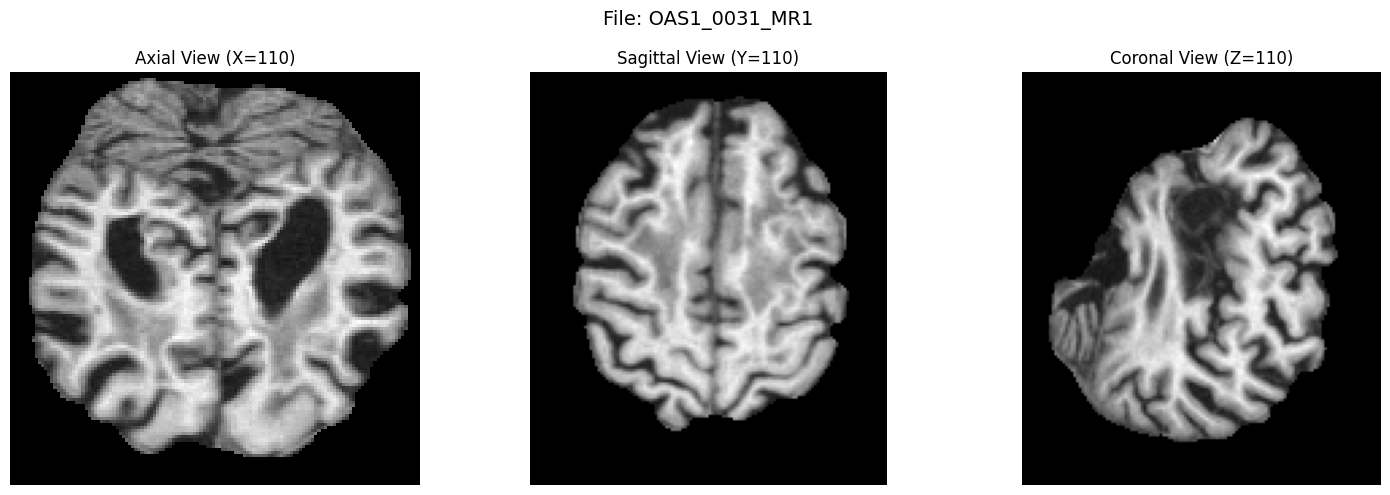

In [12]:
patient_id = "OAS1_0031_MR1"
slice_index = 110
axial_slice = slice_index
sagittal_slice = slice_index
coronal_slice = slice_index

# Đường dẫn thư mục của bạn
data_path = r"D:\YEAR 3\Lab\3D-Unet\data\processed_oasis_3d\_cache"

# 1. Lấy danh sách tất cả các file có đuôi .nii hoặc .nii.gz
nii_files = [f for f in os.listdir(data_path) if f.endswith('.nii') or f.endswith('.nii.gz')]

if not nii_files:
    print("Không tìm thấy file .nii nào trong thư mục!")
else:
    # 2. Chọn ngẫu nhiên 1 file
    file_full_path = os.path.join(data_path, f"{patient_id}.nii.gz")
    print(f"Đang hiển thị file: {patient_id}")

    # 3. Load file bằng nibabel
    img = nib.load(file_full_path)
    data = img.get_fdata()

    print(f"Shape of the 3D image: {data.shape}")

    # 4. Lấy tọa độ chính giữa của 3 trục
    x, y, z = axial_slice, sagittal_slice, coronal_slice
    print(f"Mid coordinates: X={x}, Y={y}, Z={z}")

    # 5. Vẽ ảnh 2D
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    fig.suptitle(f"File: {patient_id}", fontsize=14)

    # Trục Axial (Mặt cắt ngang)
    axes[0].imshow(data[x, :, :], cmap='gray')
    axes[0].set_title('Axial View (X={})'.format(x))
    axes[0].axis('off')

    # Trục Sagittal (Mặt cắt dọc bên)
    axes[1].imshow(data[:, y, :], cmap='gray')
    axes[1].set_title('Sagittal View (Y={})'.format(y))
    axes[1].axis('off')

    # Trục Coronal (Mặt cắt đứng ngang)
    axes[2].imshow(data[:, :, z], cmap='gray')
    axes[2].set_title('Coronal View (Z={})'.format(z))
    axes[2].axis('off')

    plt.tight_layout()
    plt.show()